In [61]:
import numpy as np
import matplotlib.pyplot as plt

In [62]:
plt.rc('font', size=14)
plt.rc('axes', labelsize=14, titlesize=14)
plt.rc('legend', fontsize=14)
plt.rc('xtick', labelsize=10)
plt.rc('ytick', labelsize=10)

<h1>Normal Equation</h1>

In [63]:
m = 200

rng = np.random.default_rng(seed=42)

X = 2*rng.random((m, 1))
y = 4 + 3*X + rng.standard_normal((m, 1))

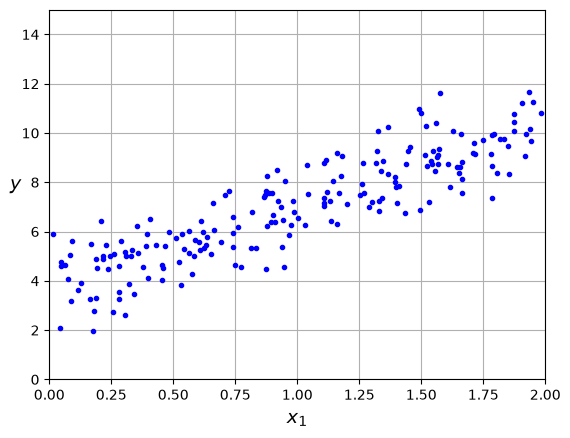

In [64]:
plt.plot(X, y, 'b.')

plt.xlabel('$x_1$')
plt.ylabel('$y$', rotation=0)
plt.axis([0, 2, 0, 15])
plt.grid(True)
plt.show()

$$\hat\theta = (X^TX)^{-1}X^Ty$$

<h3>¿De dónde sale esta fórmula?</h3>
<p>Es la solución <b>cerrada</b> (closed-form) que minimiza el MSE. Partiendo del costo:</p>

$$J(\theta) = \frac{1}{m}\|X\theta - y\|^2$$

<p>se calcula el gradiente, se iguala a cero y se despeja θ:</p>

$$\nabla J(\theta) = \frac{2}{m}X^T(X\theta - y) = 0$$

$$X^TX\,\theta = X^Ty \quad\Longrightarrow\quad \theta = (X^TX)^{-1}X^Ty$$

<p>No hay iteraciones ni <i>learning rate</i>: se obtiene θ directamente. Este mismo gradiente reaparece en Gradient Descent.</p>

<h3>ALERTA: Sobre la complejidad</h3>
<p>El cuello de botella no es solo la multiplicación, sino <b>invertir</b> X<sup>T</sup>X, que es una matriz (n+1)×(n+1) donde <i>n</i> = número de <i>features</i>. El costo crece muy rápido con el número de features (aprox. O(n<sup>2.4</sup>) a O(n<sup>3</sup>)), pero es <b>lineal respecto al número de instancias m</b>.</p>
<p>Conclusión: se vuelve lento con muchas <i>columnas</i>, no con muchas <i>filas</i>. Las predicciones sí son rápidas.</p>

In [65]:
from sklearn.preprocessing import add_dummy_feature

In [66]:
X_b = add_dummy_feature(X)

theta_best = np.linalg.inv(X_b.T @ X_b) @ X_b.T @ y

<h3>¿Por qué add_dummy_feature?</h3>
<p>Agrega una columna de unos (x<sub>0</sub> = 1) para que el término independiente θ<sub>0</sub> (bias/intercepto) quede incluido en la forma matricial Xθ.</p>
<p>Por eso <code>theta_best</code> tiene 2 valores: θ<sub>0</sub> ≈ 4 (intercepto) y θ<sub>1</sub> ≈ 3 (pendiente), que coinciden con cómo generamos los datos (y = 4 + 3x).</p>

In [67]:
X_b

array([[1.        , 1.5479121 ],
       [1.        , 0.87775688],
       [1.        , 1.71719584],
       [1.        , 1.39473606],
       [1.        , 0.1883547 ],
       [1.        , 1.9512447 ],
       [1.        , 1.5222794 ],
       [1.        , 1.57212861],
       [1.        , 0.25622727],
       [1.        , 0.90077188],
       [1.        , 0.74159605],
       [1.        , 1.85352998],
       [1.        , 1.28773024],
       [1.        , 1.64552323],
       [1.        , 0.8868284 ],
       [1.        , 0.45447744],
       [1.        , 1.10916957],
       [1.        , 0.12763451],
       [1.        , 1.65526234],
       [1.        , 1.2633288 ],
       [1.        , 1.51617548],
       [1.        , 0.70905194],
       [1.        , 1.94139605],
       [1.        , 1.78624224],
       [1.        , 1.55676699],
       [1.        , 0.38927742],
       [1.        , 0.93344201],
       [1.        , 0.08760753],
       [1.        , 0.30857898],
       [1.        , 1.36609791],
       [1.

In [68]:
theta_best

array([[3.69084138],
       [3.32960458]])

In [69]:
X_new = np.array([[0], [2]])
X_new_b = add_dummy_feature(X_new)

y_predict = X_new_b @ theta_best
y_predict

array([[ 3.69084138],
       [10.35005055]])

<b> ideal = ([[4],[10]])   ->   La diferencia es debida a el ruido aleatorio</b>

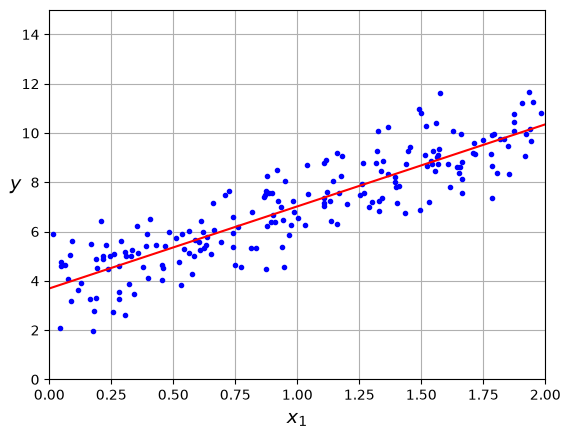

In [70]:
plt.plot(X, y, 'b.')
plt.plot(X_new, y_predict, 'r-', label='Prediction')

plt.xlabel('$x_1$')
plt.ylabel('$y$', rotation=0)
plt.axis([0, 2, 0, 15])
plt.grid(True)
plt.show()

<h1>Scikit-Learn</h1>

In [71]:
from sklearn.linear_model import LinearRegression

In [72]:
lin_reg = LinearRegression()
lin_reg.fit(X, y)
lin_reg.intercept_, lin_reg.coef_

(array([3.69084138]), array([[3.32960458]]))

In [73]:
lin_reg.predict(X_new)

array([[ 3.69084138],
       [10.35005055]])

<p>Mismo resultado que lo que hicimos hace rato</p>

<h1>Gradient Descent</h1>

<p>Se calculan las pedientes de los errores (calculando la derivada) para encontrar el mínimo el cual será el origen</p>

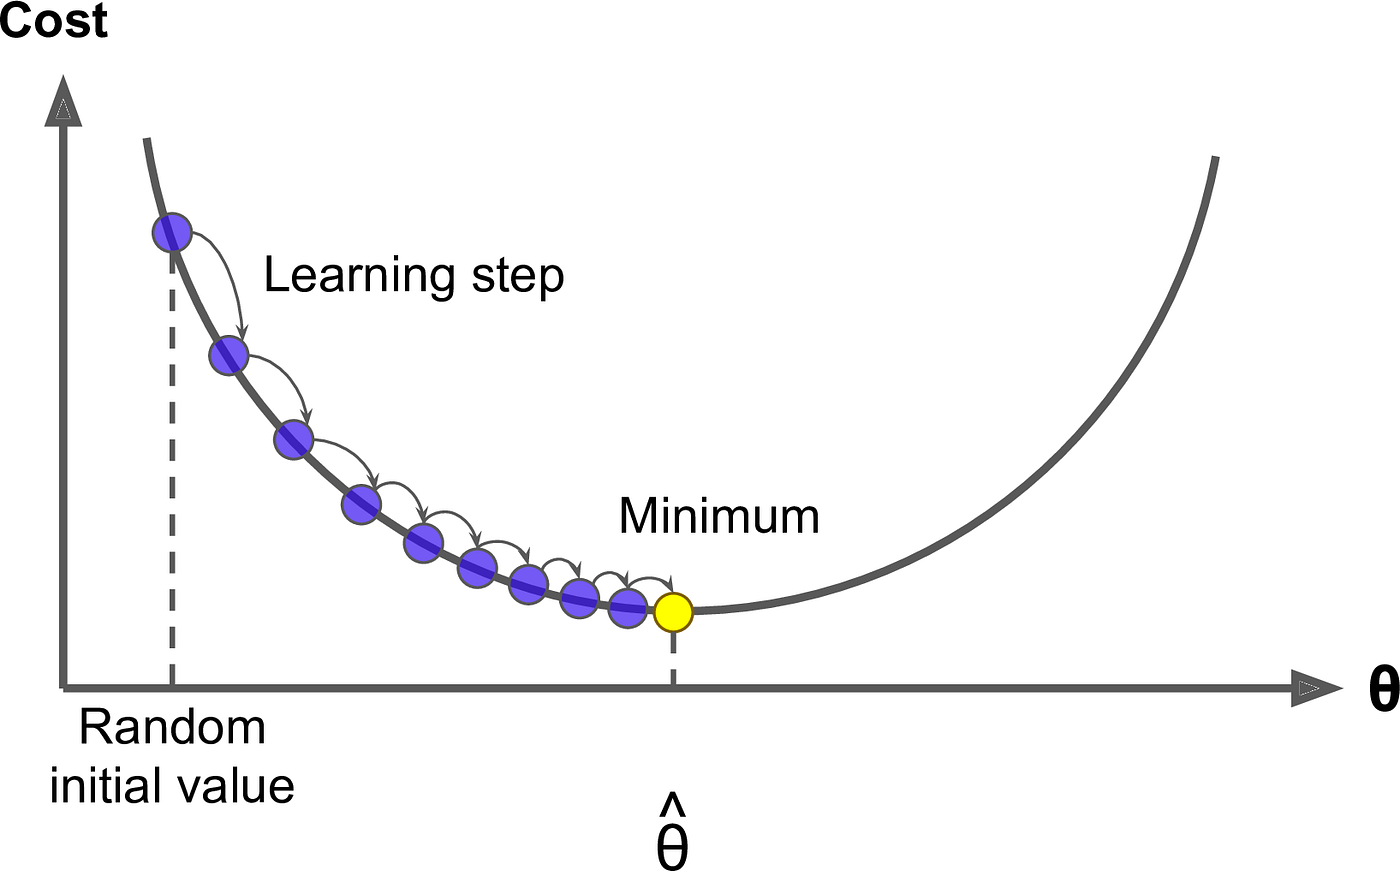

<h3>Ideas clave</h3>
<ul>
  <li>Es un algoritmo <b>iterativo</b>: ajusta θ paso a paso para minimizar el costo.</li>
  <li>Para regresión lineal el MSE es una función <b>convexa</b> (forma de tazón): tiene un único mínimo global, sin mínimos locales, así que GD siempre converge a la solución óptima (con un learning rate adecuado).</li>
  <li><b>Learning rate η:</b> si es muy pequeño converge lento (muchas iteraciones); si es muy grande oscila o <i>diverge</i>.</li>
</ul>

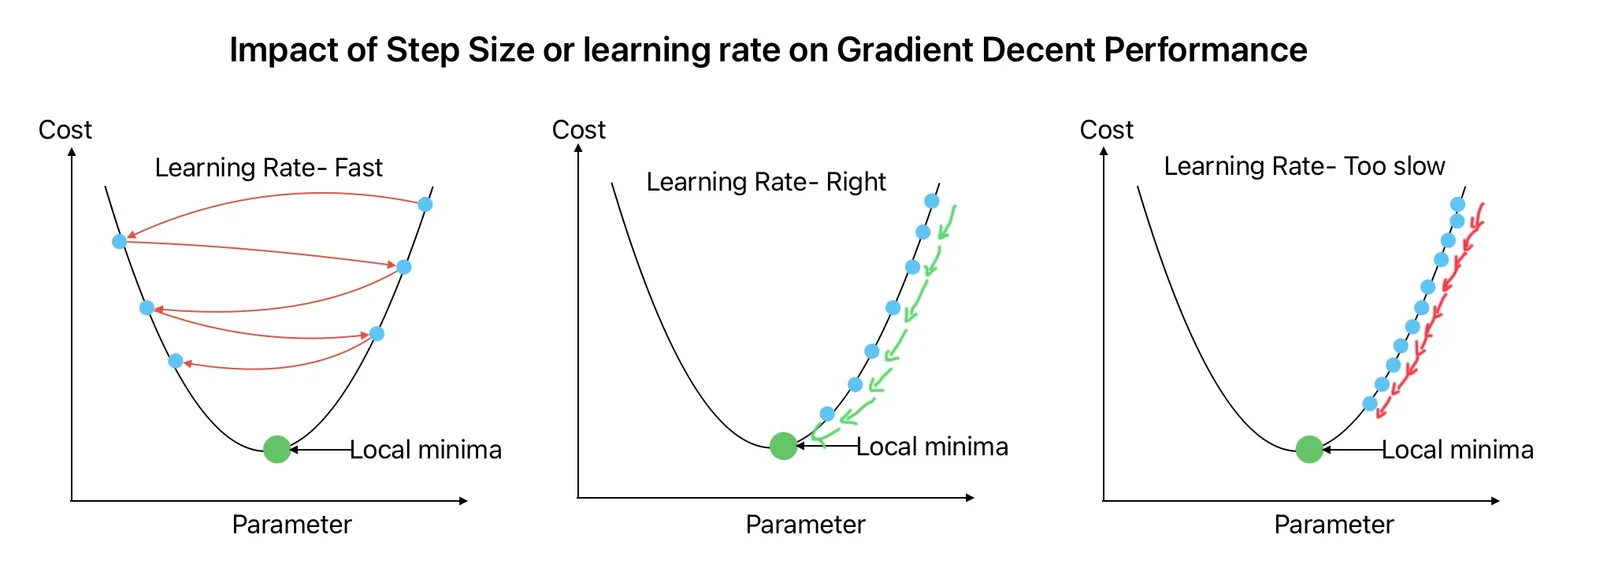

<h2>Batch Gradient Descent</h2>

<h3>¿Por qué "Batch"?</h3>
<p>En cada paso usa <b>todo</b> el training set para calcular el gradiente:</p>

$$\nabla J(\theta) = \frac{2}{m}X^T(X\theta - y)$$

<p>(es exactamente el mismo gradiente de la Normal Equation). Luego da el paso cuesta abajo:</p>

$$\theta \leftarrow \theta - \eta\,\nabla J(\theta)$$

<ul>
  <li><code>n_epochs</code> es un hiperparámetro; una alternativa es parar cuando el gradiente se hace muy pequeño (criterio de tolerancia).</li>
  <li><code>J_log</code> guarda el costo por época <b>solo para visualizar</b> la convergencia: la curva debe <b>bajar y aplanarse</b>. Si sube, el learning rate es demasiado grande.</li>
</ul>

In [74]:
eta = 0.1 #factor de aprendizaje (learning rate)
n_epochs = 1000 #número de iteraciones (número de épocas)

In [75]:
rng = np.random.default_rng(seed=42);

In [76]:
theta = rng.standard_normal((2, 1))
theta

array([[ 0.30471708],
       [-1.03998411]])

In [77]:
J_log = np.zeros(n_epochs) #Se reservan los espacios de cada iteración debido a que es más eficiente que ir creciendo una lista

for i in range(n_epochs):
    J_log[i] = (1/m) * ((X_b@theta - y)**2).sum() #Calculando el error para el dataset; NO es requerido para el gradient descent. Es únicamente
                                                  #para ver el error descender por el tiempo

    gradients = (2/m) * X_b.T @ (X_b@theta - y)
    theta = theta - eta * gradients

theta

array([[3.69084138],
       [3.32960458]])

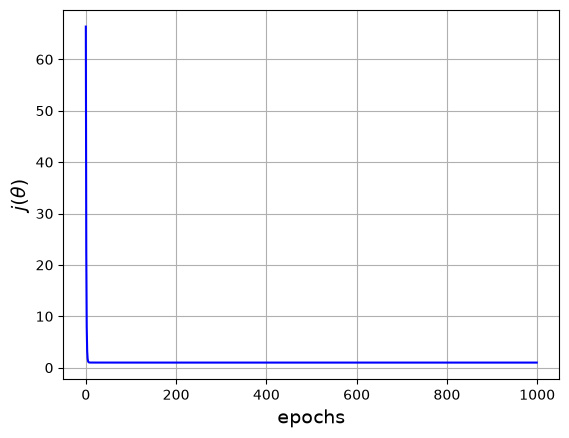

In [78]:
plt.plot(np.arange(n_epochs), J_log, 'b-')
plt.xlabel('epochs')
plt.ylabel(r'$j(\theta)$')
plt.grid(True)
plt.show()

<h1>Polynomial Regression</h1>

<h3>Sigue siendo un modelo lineal</h3>
<p>Es lineal <i>en los parámetros</i> θ; solo agregamos x<sup>2</sup>, x<sup>3</sup>, ... como nuevos features. Por eso podemos reusar <code>LinearRegression</code>.</p>
<ul>
  <li><code>PolynomialFeatures(degree=d)</code> genera todas las combinaciones hasta grado d. Con un solo feature y grado 2 da [x, x<sup>2</sup>]. Con dos features a, b y grado 2 da [a, b, a<sup>2</sup>, ab, b<sup>2</sup>]: puede crecer muchísimo (riesgo de sobreajuste).</li>
  <li><code>include_bias=False</code> porque <code>LinearRegression</code> ya agrega su propio intercepto; no queremos la columna de unos duplicada.</li>
</ul>

In [79]:
rng = np.random.default_rng(seed=42)

In [80]:
m = 200
X = 6 * rng.random((m, 1)) - 3
y = 0.5 * X**2 + X + 2 + rng.standard_normal((m, 1))

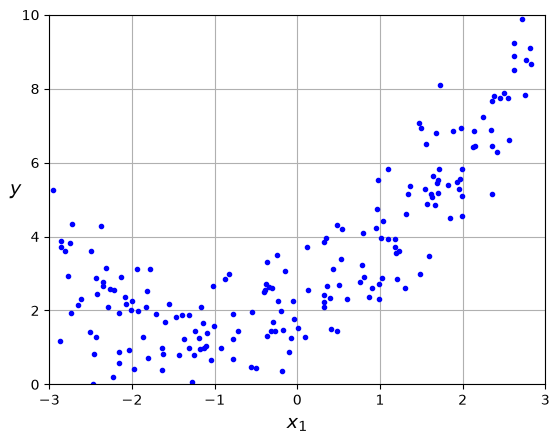

In [81]:
plt.plot(X, y, 'b.')

plt.xlabel('$x_1$')
plt.ylabel('$y$', rotation=0)
plt.axis([-3, 3, 0, 10])
plt.grid(True)
plt.show()

In [82]:
from sklearn.preprocessing import PolynomialFeatures

In [83]:
poly_features = PolynomialFeatures(degree=2, include_bias=False)
X_poly = poly_features.fit_transform(X)

In [84]:
X

array([[ 1.64373629],
       [-0.36672936],
       [ 2.15158752],
       [ 1.18420817],
       [-2.43493591],
       [ 2.85373411],
       [ 1.56683821],
       [ 1.71638583],
       [-2.2313182 ],
       [-0.29768437],
       [-0.77521185],
       [ 2.56058993],
       [ 0.86319072],
       [ 1.93656968],
       [-0.33951481],
       [-1.63656767],
       [ 0.32750872],
       [-2.61709646],
       [ 1.96578703],
       [ 0.78998639],
       [ 1.54852644],
       [-0.87284419],
       [ 2.82418815],
       [ 2.35872673],
       [ 1.67030098],
       [-1.83216775],
       [-0.19967398],
       [-2.73717741],
       [-2.07426305],
       [ 1.09829372],
       [ 1.46857294],
       [ 2.80505839],
       [-1.04504785],
       [-0.77724176],
       [-0.18266513],
       [-1.86317185],
       [-2.22047097],
       [-0.14577044],
       [-1.63854391],
       [ 1.01888397],
       [-0.37708849],
       [ 1.99606918],
       [ 1.20159061],
       [-1.12580015],
       [ 1.99355881],
       [ 1

In [85]:
print(X_poly.shape)
X_poly

(200, 2)


array([[ 1.64373629e+00,  2.70186900e+00],
       [-3.66729361e-01,  1.34490425e-01],
       [ 2.15158752e+00,  4.62932885e+00],
       [ 1.18420817e+00,  1.40234900e+00],
       [-2.43493591e+00,  5.92891290e+00],
       [ 2.85373411e+00,  8.14379837e+00],
       [ 1.56683821e+00,  2.45498198e+00],
       [ 1.71638583e+00,  2.94598032e+00],
       [-2.23131820e+00,  4.97878093e+00],
       [-2.97684373e-01,  8.86159857e-02],
       [-7.75211855e-01,  6.00953420e-01],
       [ 2.56058993e+00,  6.55662081e+00],
       [ 8.63190720e-01,  7.45098220e-01],
       [ 1.93656968e+00,  3.75030212e+00],
       [-3.39514807e-01,  1.15270304e-01],
       [-1.63656767e+00,  2.67835374e+00],
       [ 3.27508722e-01,  1.07261963e-01],
       [-2.61709646e+00,  6.84919390e+00],
       [ 1.96578703e+00,  3.86431866e+00],
       [ 7.89986395e-01,  6.24078504e-01],
       [ 1.54852644e+00,  2.39793414e+00],
       [-8.72844191e-01,  7.61856982e-01],
       [ 2.82418815e+00,  7.97603869e+00],
       [ 2.

In [88]:
lin_reg = LinearRegression()
lin_reg.fit(X_poly, y)
lin_reg.intercept_, lin_reg.coef_

(array([2.00540719]), array([[1.11022126, 0.50526985]]))

<h3>Verificación</h3>
<p>El modelo recupera aprox. <code>intercept ≈ 2</code>, <code>coef ≈ [1, 0.5]</code>, que coincide con la ecuación con la que generamos los datos:</p>

$$y = 0.5\,x^2 + x + 2 + \text{ruido}$$

<ul>
  <li>Grado <b>muy alto</b> lleva a <i>overfitting</i> (la curva se retuerce para seguir el ruido). Grado <b>muy bajo</b> lleva a <i>underfitting</i>. Es el compromiso <i>bias–variance</i>.</li>
</ul>

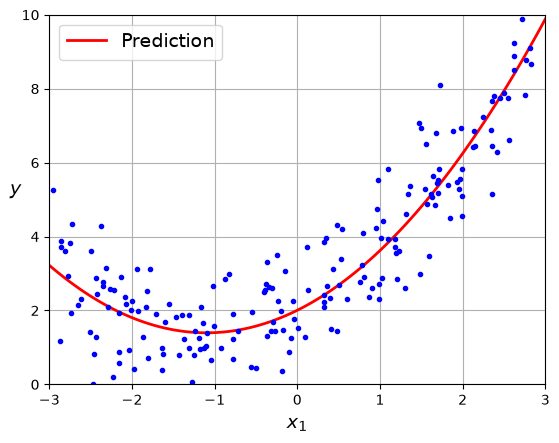

In [92]:
X_new = np.linspace(-3, 3, 100).reshape(100, 1)
X_new_poly = poly_features.transform(X_new)
y_new = lin_reg.predict(X_new_poly)


plt.plot(X_new, y_new, 'r-', linewidth=2, label='Prediction')
plt.plot(X, y, 'b.')

plt.xlabel('$x_1$')
plt.ylabel('$y$', rotation=0)
plt.legend(loc = 'upper left')
plt.axis([-3, 3, 0, 10])
plt.grid(True)
plt.show()